In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "swanson_7K_pbmc_teaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

In [2]:
pd.DataFrame.from_dict(
    {
        name: {
            "cells": ds.get_assay(name).rawData.shape[0],
            "raw features": ds.get_assay(name).rawData.shape[1],
            "active features": int(ds.get_assay(name).feats.fetch_all("I").sum()),
        }
        for name in ("RNA", "ATAC", "ADT")
    },
    orient="index",
)

,cells,raw features,active features
RNA,7069,36601,36601
ATAC,7069,240122,240122
ADT,7069,46,46


In [3]:
pd.Series(
    {
        "source cells retained": ds.cells.N,
        "active exact W3 matches": int(ds.cells.fetch_all("I").sum()),
        "Figure 4 W3 labels": 6_333,
        "Figure 4 labels absent from the pinned RDS": 139,
    }
)

source cells retained                         7069
active exact W3 matches                       6194
Figure 4 W3 labels                            6333
Figure 4 labels absent from the pinned RDS     139
dtype: int64

In [4]:
pd.Series(ds.cells.fetch("tea_cell_type", key="I")).value_counts()

T.CD4.Memory        1450
T.CD4.Naive         1274
B.Naive              981
Mono.CD14            789
T.CD8.Effector       709
T.CD8.Naive          372
NK                   351
B.Activated          205
Mono.CD16             39
Platelets             14
DC.Myeloid             9
T.DoubleNegative       1
Name: count, dtype: int64

In [5]:
modality_layouts = {}
for assay in ("RNA", "ATAC", "ADT"):
    [modality_layouts[assay]] = ds.list_artifacts(
        from_assay=assay,
        kind="embedding",
        complete_only=True,
    )

integrated_graphs = {
    ds.inspect_artifact(ref).parameters["method"]: ref
    for ref in ds.list_artifacts(
        scope="datastore",
        kind="integrated_graph",
        complete_only=True,
    )
}


def linked_output(graph, kind):
    [result] = [
        ref
        for ref in ds.list_artifacts(scope="datastore", kind=kind, complete_only=True)
        if scarf.ArtifactRef.from_dict(ds.inspect_artifact(ref).inputs["graph"])
        == graph
    ]
    return result


snn_ref = integrated_graphs["snn"]
wnn_ref = integrated_graphs["wnn"]
snn_layout = linked_output(snn_ref, "embedding")
wnn_layout = linked_output(wnn_ref, "embedding")

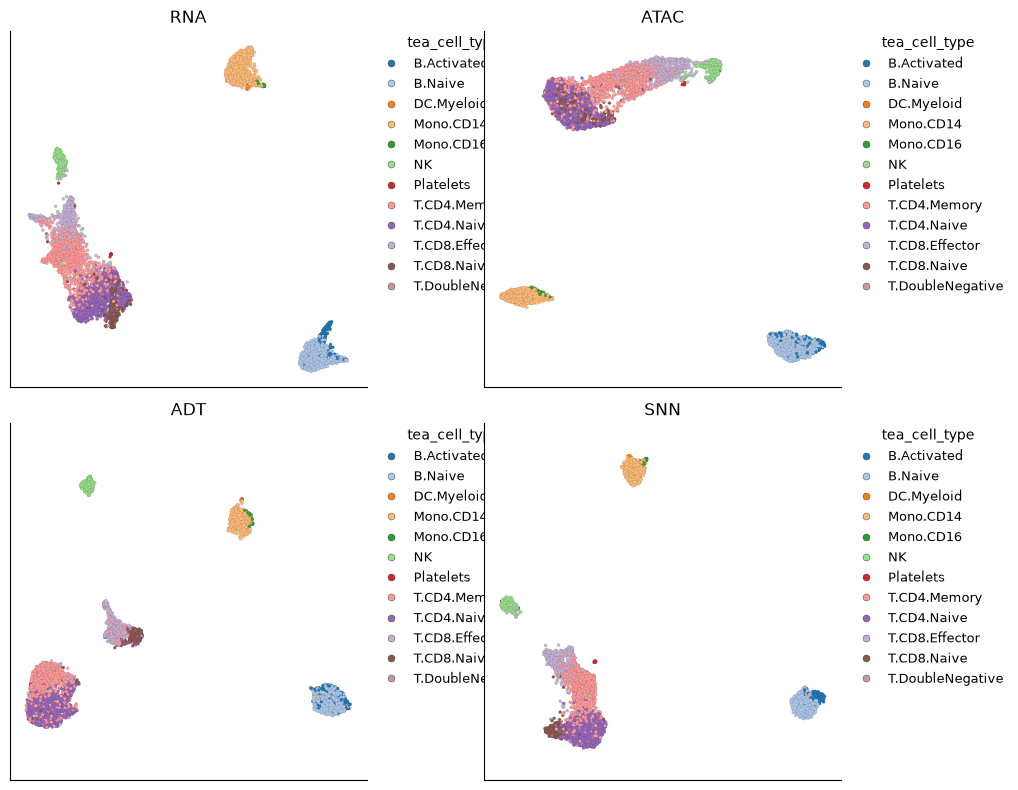

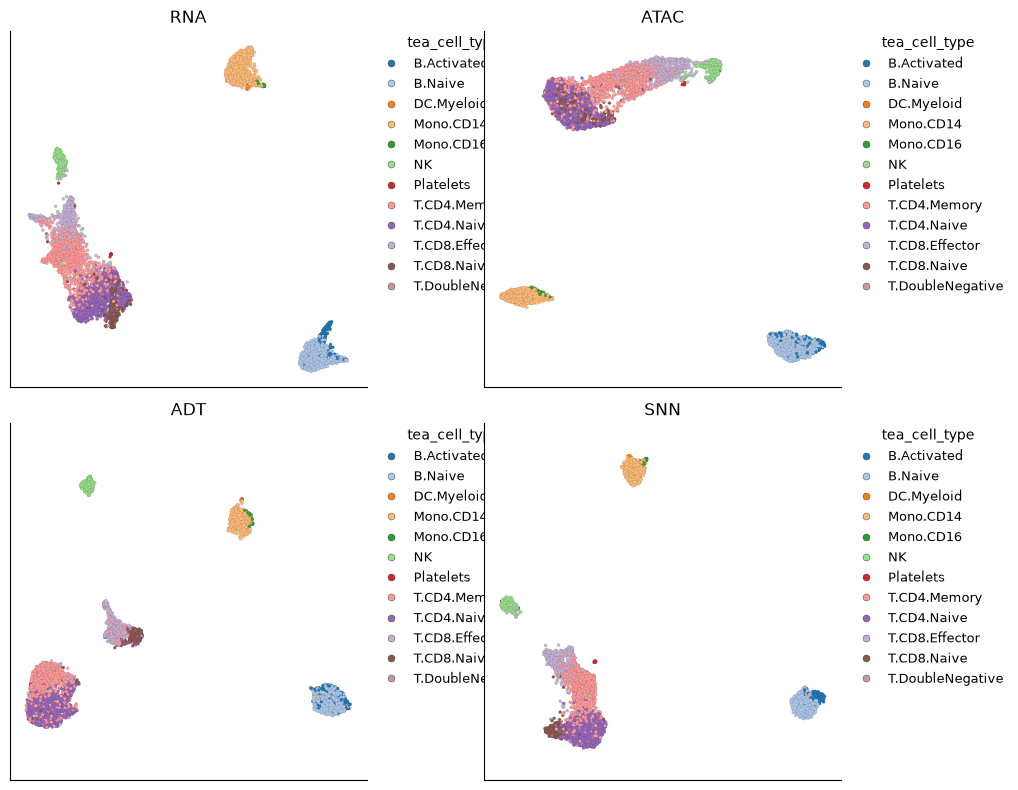

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
for axis, (label, layout) in zip(
    axes.flat,
    (*modality_layouts.items(), ("SNN", snn_layout)),
    strict=True,
):
    ds.plots.embedding(
        layout=layout,
        color_by="tea_cell_type",
        point_size=5,
        legend_loc="right",
        target=axis,
        show=False,
    )
    axis.set_title(label)
figure.tight_layout()
figure

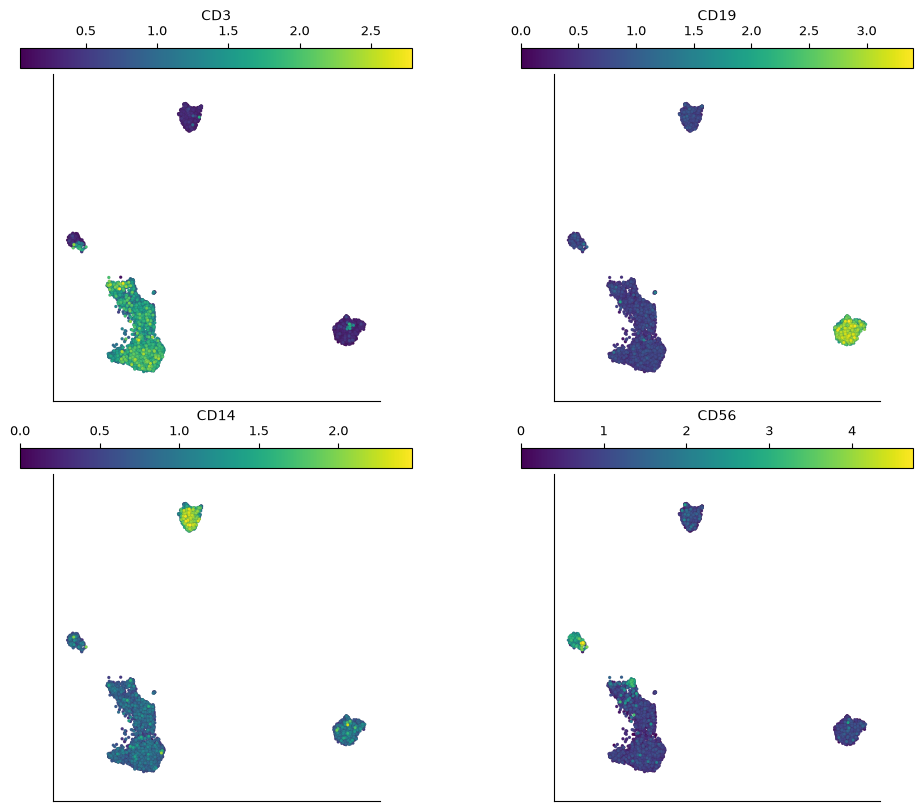

In [7]:
ds.plots.embedding(
    layout=snn_layout,
    from_assay="ADT",
    color_by=["CD3", "CD19", "CD14", "CD56"],
    n_columns=2,
    point_size=5,
    sort_values=True,
    show_titles=True,
    figsize=(10, 8),
)

In [8]:
wnn_status = ds.inspect_artifact(wnn_ref)
assays = list(wnn_status.parameters["assays"])

assert assays == ["RNA", "ATAC", "ADT"]
pd.Series(
    {
        "artifact kind": wnn_ref.kind,
        "artifact id": wnn_ref.artifact_id,
        "complete": wnn_status.complete,
        "ordered assays": ", ".join(wnn_status.parameters["assays"]),
        "input roles": ", ".join(sorted(wnn_status.inputs)),
    }
)

artifact kind                                      integrated_graph
artifact id       2eaeca473b7bb3bbebe51bf995767e077d87b4978b6508...
complete                                                       True
ordered assays                                       RNA, ATAC, ADT
input roles            cell_selection, source_0, source_1, source_2
dtype: object

In [9]:
weight_values = np.asarray(ds.load_artifact(wnn_ref)["modality_weights"][:])

assert weight_values.shape == (6_194, 3)
assert np.isfinite(weight_values).all()
assert (weight_values >= 0).all()
assert np.allclose(weight_values.sum(axis=1), 1, atol=1e-6)

pd.Series(
    {
        "shape": str(weight_values.shape),
        "minimum weight": float(weight_values.min()),
        "maximum weight": float(weight_values.max()),
        "maximum row-sum error": float(np.abs(weight_values.sum(axis=1) - 1).max()),
    }
)

shape                    (6194, 3)
minimum weight                 0.0
maximum weight                 1.0
maximum row-sum error          0.0
dtype: object

In [10]:
weight_frame = pd.DataFrame(
    weight_values,
    columns=[f"{assay} weight" for assay in assays],
)
weight_frame["tea_cell_type"] = ds.cells.fetch("tea_cell_type", key="I")
weight_columns = [f"{assay} weight" for assay in assays]
weight_frame.groupby("tea_cell_type")[weight_columns].agg(["count", "mean"]).round(3)

RNA weight        ATAC weight        ADT weight       
                      count   mean       count   mean      count   mean
tea_cell_type                                                          
B.Activated             205  0.283         205  0.471        205  0.245
B.Naive                 981  0.195         981  0.444        981  0.361
DC.Myeloid                9  0.186           9  0.236          9  0.578
Mono.CD14               789  0.416         789  0.193        789  0.391
Mono.CD16                39  0.834          39  0.076         39  0.090
NK                      351  0.257         351  0.360        351  0.383
Platelets                14  0.275          14  0.239         14  0.486
T.CD4.Memory           1450  0.159        1450  0.301       1450  0.540
T.CD4.Naive            1274  0.157        1274  0.225       1274  0.618
T.CD8.Effector          709  0.186         709  0.363        709  0.452
T.CD8.Naive             372  0.124         372  0.192        372  0.684
T.DoubleNegative          1  0.003           1  0.000          1  0.997

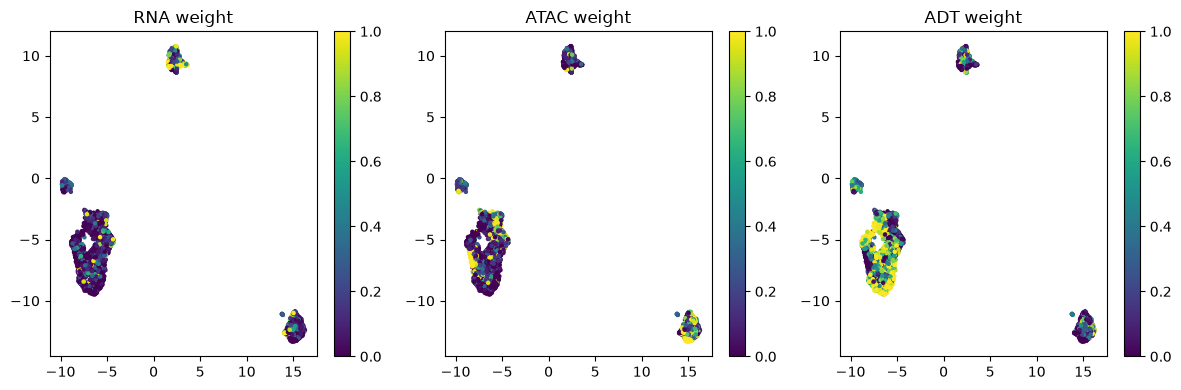

In [11]:
wnn_coordinates = np.asarray(ds.load_artifact(wnn_layout)["values"][:])
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, values, title in zip(
    axes,
    weight_values.T,
    weight_columns,
    strict=True,
):
    points = axis.scatter(
        wnn_coordinates[:, 0],
        wnn_coordinates[:, 1],
        c=values,
        s=5,
    )
    axis.set_title(title)
    figure.colorbar(points, ax=axis)
figure.tight_layout()

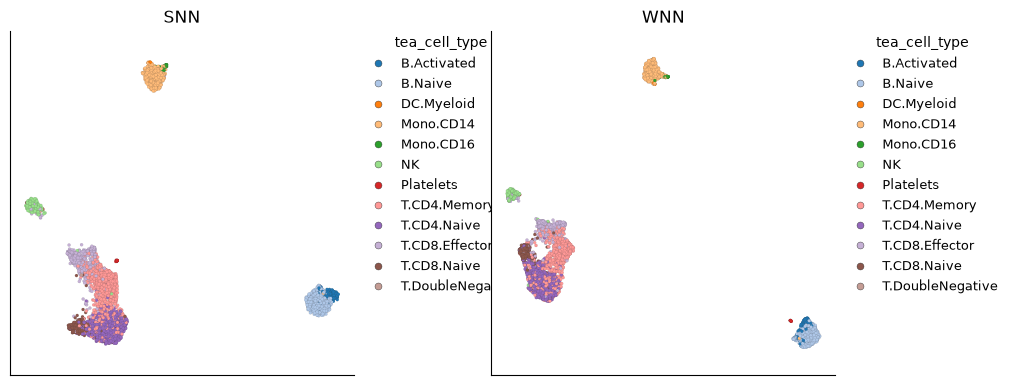

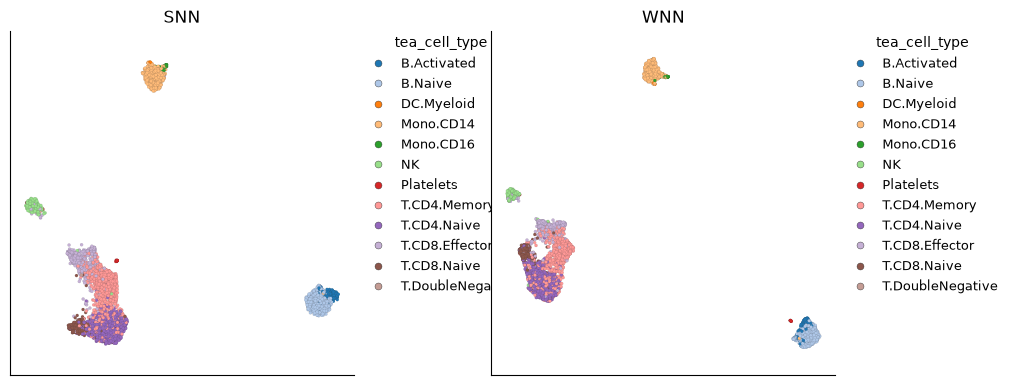

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, (label, layout) in zip(
    axes,
    (("SNN", snn_layout), ("WNN", wnn_layout)),
    strict=True,
):
    ds.plots.embedding(
        layout=layout,
        color_by="tea_cell_type",
        point_size=5,
        legend_loc="right",
        target=axis,
        show=False,
    )
    axis.set_title(label)
figure.tight_layout()
figure

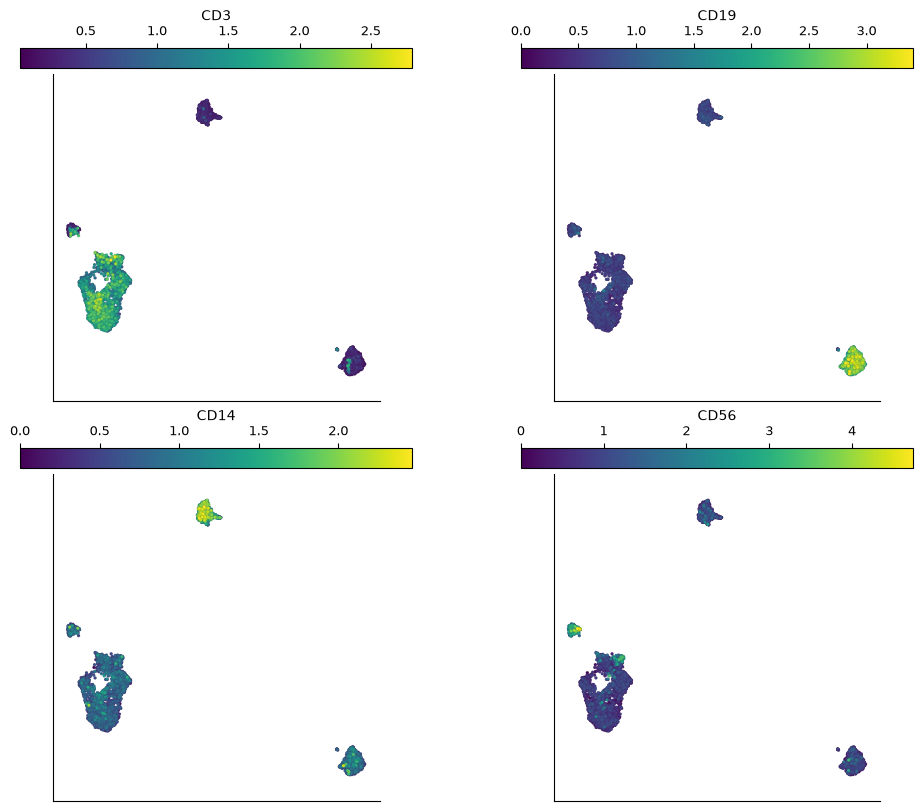

In [13]:
ds.plots.embedding(
    layout=wnn_layout,
    from_assay="ADT",
    color_by=["CD3", "CD19", "CD14", "CD56"],
    n_columns=2,
    point_size=5,
    sort_values=True,
    show_titles=True,
    figsize=(10, 8),
)